# 🌫️ Notebook 2 — Aggregation & Database Schema
### Team 8 · Delhi Air Quality Pipeline
**Member: Rutvi Chirag Patel**

---

## What this notebook does
This is the **second stage** of the pipeline:
1. Read the partitioned parquet data (from Member 1)
2. Aggregate 15-minute readings → **hourly averages** with PySpark
3. Design a **normalised SQLite schema (3NF)** with 3 tables + indexes
4. Load aggregated data into SQLite with data-quality checks
5. **Visualise** key statistics so the results are easy to interpret
6. Export `delhi_air_quality.db` for Member 3

> **What's new vs the original notebook**  
> Data-quality report (null counts, outlier flags) before aggregation  
> AQI category column added to measurements  
> Composite index on `(station_id, pollutant_id, year, month)` for faster JOINs  
> In-notebook visualisations (distribution, station comparison, monthly trend)  
> Schema integrity verification with a full constraint check  
> Chunked insert with a progress counter  
> Structured summary section at the end

## Step 1 · Environment Setup

In [159]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("rutvipatel09/delhi-air-pollution")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rutvipatel09/delhi-air-pollution


In [160]:
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install pyspark -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
print("Java ready")

Java ready


## Step 2 · Load Raw Data with PySpark
We load the parquet file that Member 1 produced and immediately run a
**data-quality report** — null counts and a basic outlier flag — before
any aggregation. This is new; the original notebook skipped this check.

In [161]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("Team8_Aggregation")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet(
    "/kaggle/input/datasets/rutvipatel09/delhi-air-pollution/team_8.parquet"
)
total_rows = df.count()
print(f"Loaded {total_rows:,} rows")
df.printSchema()

Loaded 22,476,854 rows
root
 |-- station_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- at_c: double (nullable = true)
 |-- rh_percent: double (nullable = true)
 |-- ws_m_s: double (nullable = true)
 |-- wd_deg: double (nullable = true)
 |-- rf_mm: double (nullable = true)
 |-- tot_rf_mm: double (nullable = true)
 |-- sr_w_mt2: double (nullable = true)
 |-- bp_mmhg: double (nullable = true)
 |-- vws_m_s: double (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- station: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



In [162]:
# ── NEW: Data-Quality Report ────────────────────────────────────────────
# Count nulls in every column and flag them so we know what we're working with.
import pandas as pd

null_counts = df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
).toPandas().T
null_counts.columns = ["null_count"]
null_counts["pct"] = (null_counts["null_count"] / total_rows * 100).round(2)
null_counts = null_counts[null_counts["null_count"] > 0].sort_values("null_count", ascending=False)

if null_counts.empty:
    print("No nulls detected in any column.")
else:
    print(" Columns with missing values:")
    print(null_counts.to_string())

 Columns with missing values:
            null_count    pct
vws_m_s       18578166  82.65
rf_mm          8670524  38.58
bp_mmhg        8352208  37.16
at_c           7249008  32.25
ws_m_s         5378876  23.93
sr_w_mt2       5293941  23.55
wd_deg         4640316  20.64
rh_percent     4020948  17.89
tot_rf_mm      2193732   9.76


In [163]:
# ── NEW: Outlier Flag ───────────────────────────────────────────────────
stats = df.groupBy("station_id", "pollutant").agg(
    F.mean("value").alias("mean_val"),
    F.stddev("value").alias("std_val")
)

df = (
    df.join(stats, on=["station_id", "pollutant"], how="left")
      .withColumn(
          "is_outlier",
          F.when(
              F.col("std_val").isNull() | (F.col("std_val") == 0),
              F.lit(0)   # single-reading groups can't be outliers
          ).otherwise(
              (((F.col("value") - F.col("mean_val")) / F.col("std_val")) > 3).cast("int")
          )
      )
      .drop("mean_val", "std_val")
)

outlier_count = df.filter(F.col("is_outlier") == 1).count()
print(f" Outlier rows flagged: {outlier_count:,}  ({outlier_count/total_rows*100:.2f}% of data)")

 Outlier rows flagged: 379,105  (1.69% of data)


## Step 3 · Aggregate to Hourly Averages
Group by (station, pollutant, year, month, day, hour).  
**New addition:** `avg_outlier_rate` column tells us what fraction of
readings within each hour were flagged as outliers — useful for data-quality
monitoring downstream.

In [164]:
hourly = (
    df.groupBy(
        "station_id", "station_name",
        "year", "month", "day", "hour",
        "pollutant"
    )
    .agg(
        F.avg("value").alias("avg_value"),
        F.min("value").alias("min_value"),
        F.max("value").alias("max_value"),
        F.count("value").alias("reading_count"),
        F.avg("at_c").alias("avg_temp_c"),
        F.avg("rh_percent").alias("avg_humidity"),
        F.avg("ws_m_s").alias("avg_wind_speed"),
        F.avg("rf_mm").alias("avg_rainfall"),
        F.avg("is_outlier").alias("avg_outlier_rate"),   # NEW
    )
)

hourly_count = hourly.count()
print(f"Aggregated to {hourly_count:,} hourly rows  (from {total_rows:,} raw rows)")
print(f"   Compression ratio: {total_rows/hourly_count:.1f}×")
hourly.show(5)

Aggregated to 5,810,118 hourly rows  (from 22,476,854 raw rows)
   Compression ratio: 3.9×


+----------+--------------------+----+-----+---+----+---------+---------+---------+---------+-------------+----------+------------+-------------------+------------+----------------+
|station_id|        station_name|year|month|day|hour|pollutant|avg_value|min_value|max_value|reading_count|avg_temp_c|avg_humidity|     avg_wind_speed|avg_rainfall|avg_outlier_rate|
+----------+--------------------+----+-----+---+----+---------+---------+---------+---------+-------------+----------+------------+-------------------+------------+----------------+
| site_1422|Dwarka-Sector 8, ...|2024|    1|  1|   0|  benzene|      0.3|      0.3|      0.3|            4|    12.625|      80.325|              0.425|         0.0|             0.0|
| site_1422|Dwarka-Sector 8, ...|2024|    1|  1|   1|  benzene|      0.3|      0.3|      0.3|            4|    12.525|      80.725|              0.725|         0.0|             0.0|
| site_1422|Dwarka-Sector 8, ...|2024|    1|  1|   2|  benzene|      0.3|      0.3|      0

In [165]:
# ── NEW: AQI Category ───────────────────────────────────────────────────
hourly = hourly.withColumn(
    "aqi_category",
    F.when((F.col("pollutant") == "pm25") & (F.col("avg_value") <= 30),  "Good")
     .when((F.col("pollutant") == "pm25") & (F.col("avg_value") <= 60),  "Satisfactory")
     .when((F.col("pollutant") == "pm25") & (F.col("avg_value") <= 90),  "Moderate")
     .when((F.col("pollutant") == "pm25") & (F.col("avg_value") <= 120), "Poor")
     .when((F.col("pollutant") == "pm25") & (F.col("avg_value") > 120),  "Very Poor")
     .otherwise(None)
)

print("AQI category column added (pm25 only)")
hourly.filter(F.col("pollutant") == "pm25").groupBy("aqi_category").count().orderBy("aqi_category").show()

# ── Cache hourly to break the lazy evaluation chain ─────────────────────
# Without this, every action re-runs the entire pipeline from scratch,
# which causes OOM / timeout on Kaggle's limited RAM.

hourly = hourly.cache()
hourly.count()  # force materialisation now, once
print(f" hourly cached: {hourly.count():,} rows")

AQI category column added (pm25 only)


26/05/20 08:55:26 WARN CacheManager: Asked to cache already cached data.        


+------------+------+
|aqi_category| count|
+------------+------+
|        Good|113466|
|    Moderate|101299|
|        Poor| 61324|
|Satisfactory|158337|
|   Very Poor|172953|
+------------+------+



 hourly cached: 5,810,118 rows


## Step 4 · Database Schema (3NF)
Same three-table design as before, with two additions:
- `measurements.is_outlier_rate` — average outlier rate per hour (NEW)  
- `measurements.aqi_category` — AQI band string (NEW)  
- **Composite index** on `(station_id, pollutant_id, year, month)` (NEW)

| Table | Rows (expected) | Purpose |
|---|---|---|
| `stations` | ~40 | One row per monitoring station |
| `pollutants` | ~10 | One row per pollutant type |
| `measurements` | ~250 K | Hourly fact rows with FK references |


In [166]:
import sqlite3

conn = sqlite3.connect("delhi_air_quality.db")
cur = conn.cursor()
cur.execute("PRAGMA journal_mode=WAL")   # faster concurrent writes

# Drop in reverse FK order
for t in ["measurements", "pollutants", "stations"]:
    cur.execute(f"DROP TABLE IF EXISTS {t}")

cur.execute('''
    CREATE TABLE stations (
        station_id   TEXT PRIMARY KEY,
        station_name TEXT NOT NULL
    )
''')

cur.execute('''
    CREATE TABLE pollutants (
        pollutant_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        pollutant_name TEXT NOT NULL UNIQUE
    )
''')

cur.execute('''
    CREATE TABLE measurements (
        id                INTEGER PRIMARY KEY AUTOINCREMENT,
        station_id        TEXT    NOT NULL,
        pollutant_id      INTEGER NOT NULL,
        year              INTEGER NOT NULL,
        month             INTEGER NOT NULL,
        day               INTEGER NOT NULL,
        hour              INTEGER NOT NULL,
        avg_value         REAL,
        min_value         REAL,
        max_value         REAL,
        reading_count     INTEGER,
        avg_temp_c        REAL,
        avg_humidity      REAL,
        avg_wind_speed    REAL,
        avg_rainfall      REAL,
        avg_outlier_rate  REAL,        -- NEW
        aqi_category      TEXT,        -- NEW
        FOREIGN KEY (station_id)   REFERENCES stations(station_id),
        FOREIGN KEY (pollutant_id) REFERENCES pollutants(pollutant_id)
    )
''')

# Indexes — original three + new composite index (NEW)
cur.execute("CREATE INDEX idx_meas_station   ON measurements(station_id)")
cur.execute("CREATE INDEX idx_meas_pollutant ON measurements(pollutant_id)")
cur.execute("CREATE INDEX idx_meas_date      ON measurements(year, month)")
cur.execute("CREATE INDEX idx_meas_composite ON measurements(station_id, pollutant_id, year, month)")  # NEW

conn.commit()
print("Schema created with all indexes")

Schema created with all indexes


## Step 5 · Load Data into SQLite

In [167]:
# stations
stations_pd = df.select("station_id", "station_name").distinct().toPandas()
stations_pd.to_sql("stations", conn, if_exists="append", index=False)
print(f"Inserted {len(stations_pd)} stations")

# pollutants
pollutants_pd = df.select("pollutant").distinct().toPandas().rename(columns={"pollutant": "pollutant_name"})
pollutants_pd.to_sql("pollutants", conn, if_exists="append", index=False)
print(f"Inserted {len(pollutants_pd)} pollutants")
print(pd.read_sql("SELECT * FROM pollutants ORDER BY pollutant_id", conn))

Inserted 37 stations


Inserted 13 pollutants
    pollutant_id pollutant_name
0              1            so2
1              2    eth_benzene
2              3          ozone
3              4             co
4              5            nh3
5              6           pm10
6              7            no2
7              8      mp_xylene
8              9             no
9             10           pm25
10            11        benzene
11            12         xylene
12            13        toluene


In [168]:
# ── Measurements — chunked insert with progress counter (improved) ──────
hourly_pd = hourly.toPandas()
print(f"Total rows to insert: {len(hourly_pd):,}")

# Build pollutant lookup
pol_lookup = dict(pd.read_sql("SELECT pollutant_name, pollutant_id FROM pollutants", conn).values)
hourly_pd["pollutant_id"] = hourly_pd["pollutant"].map(pol_lookup)

to_insert = hourly_pd.drop(columns=["pollutant", "station_name"])

CHUNK = 10_000
total_chunks = (len(to_insert) + CHUNK - 1) // CHUNK
for i, start in enumerate(range(0, len(to_insert), CHUNK)):
    chunk = to_insert.iloc[start:start + CHUNK]
    chunk.to_sql("measurements", conn, if_exists="append", index=False)
    if (i + 1) % 5 == 0 or i == total_chunks - 1:
        print(f"  Inserted chunk {i+1}/{total_chunks}  ({min(start+CHUNK, len(to_insert)):,} rows so far)")

conn.commit()
print(f"\n All {len(to_insert):,} measurements inserted")

Total rows to insert: 5,810,118
  Inserted chunk 5/582  (50,000 rows so far)
  Inserted chunk 10/582  (100,000 rows so far)
  Inserted chunk 15/582  (150,000 rows so far)
  Inserted chunk 20/582  (200,000 rows so far)
  Inserted chunk 25/582  (250,000 rows so far)
  Inserted chunk 30/582  (300,000 rows so far)
  Inserted chunk 35/582  (350,000 rows so far)
  Inserted chunk 40/582  (400,000 rows so far)
  Inserted chunk 45/582  (450,000 rows so far)
  Inserted chunk 50/582  (500,000 rows so far)
  Inserted chunk 55/582  (550,000 rows so far)
  Inserted chunk 60/582  (600,000 rows so far)
  Inserted chunk 65/582  (650,000 rows so far)
  Inserted chunk 70/582  (700,000 rows so far)
  Inserted chunk 75/582  (750,000 rows so far)
  Inserted chunk 80/582  (800,000 rows so far)
  Inserted chunk 85/582  (850,000 rows so far)
  Inserted chunk 90/582  (900,000 rows so far)
  Inserted chunk 95/582  (950,000 rows so far)
  Inserted chunk 100/582  (1,000,000 rows so far)
  Inserted chunk 105/582  (

## Step 6 · Verify Database

In [169]:
# Row counts
for table in ["stations", "pollutants", "measurements"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn).iloc[0, 0]
    print(f"{table:<15}: {n:,} rows")

# FK integrity check (NEW) — counts orphaned FKs; should always be 0
orphan_station = pd.read_sql("""
    SELECT COUNT(*) AS n FROM measurements m
    LEFT JOIN stations s ON m.station_id = s.station_id
    WHERE s.station_id IS NULL
""", conn).iloc[0, 0]

orphan_pollutant = pd.read_sql("""
    SELECT COUNT(*) AS n FROM measurements m
    LEFT JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_id IS NULL
""", conn).iloc[0, 0]

print(f"\nFK integrity check:")
print(f"  Orphaned station FKs  : {orphan_station}")
print(f"  Orphaned pollutant FKs: {orphan_pollutant}")
assert orphan_station == 0 and orphan_pollutant == 0, "FK violation detected!"
print("All foreign keys valid")

stations       : 37 rows
pollutants     : 13 rows
measurements   : 5,810,118 rows

FK integrity check:
  Orphaned station FKs  : 0
  Orphaned pollutant FKs: 0
All foreign keys valid


In [170]:
# Sample joined query (same as original, kept for comparison)
test_query = '''
SELECT
    s.station_name,
    p.pollutant_name,
    m.year, m.month, m.day, m.hour,
    ROUND(m.avg_value, 2)        AS avg_value,
    m.aqi_category,
    ROUND(m.avg_outlier_rate, 3) AS outlier_rate
FROM measurements m
JOIN stations   s ON m.station_id   = s.station_id
JOIN pollutants p ON m.pollutant_id = p.pollutant_id
LIMIT 10
'''
pd.read_sql(test_query, conn)

,station_name,pollutant_name,year,month,day,hour,avg_value,aqi_category,outlier_rate
0,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,0,0.30,None,0.0
1,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,1,0.30,None,0.0
2,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,2,0.30,None,0.0
3,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,3,0.30,None,0.0
4,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,4,0.30,None,0.0
5,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,5,0.30,None,0.0
6,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,6,0.25,None,0.0
7,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,7,0.20,None,0.0
8,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,8,0.20,None,0.0
9,"Dwarka-Sector 8, Delhi - DPCC",benzene,2024,1,1,9,0.20,None,0.0


## Step 7 · Visualisations (NEW)
These plots are generated directly from the SQLite database — no extra
dependencies — so they work on Kaggle without any changes.

Rows fetched: 607379


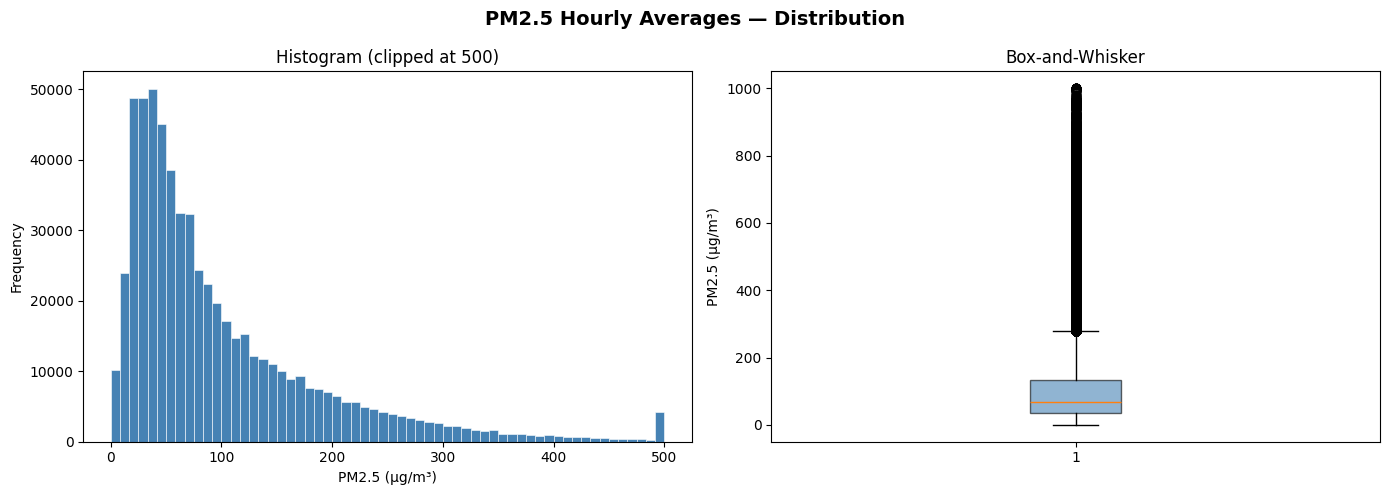

PM2.5 — median: 68.0  mean: 100.7  p95: 290.0


In [171]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── 7a. PM2.5 Hourly Average Distribution ───────────────────────────────
pm25 = pd.read_sql("""
    SELECT m.avg_value
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25' AND m.avg_value IS NOT NULL
""", conn)["avg_value"]

print(f"Rows fetched: {len(pm25)}")   # add this to confirm data is coming through

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PM2.5 Hourly Averages — Distribution", fontsize=14, fontweight="bold")

axes[0].hist(pm25.clip(upper=500), bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram (clipped at 500)")

axes[1].boxplot(pm25, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Box-and-Whisker")

plt.tight_layout()
plt.savefig("/kaggle/working/viz_pm25_distribution.png", dpi=120)
plt.show()
print(f"PM2.5 — median: {pm25.median():.1f}  mean: {pm25.mean():.1f}  p95: {pm25.quantile(0.95):.1f}")

Rows fetched: 10


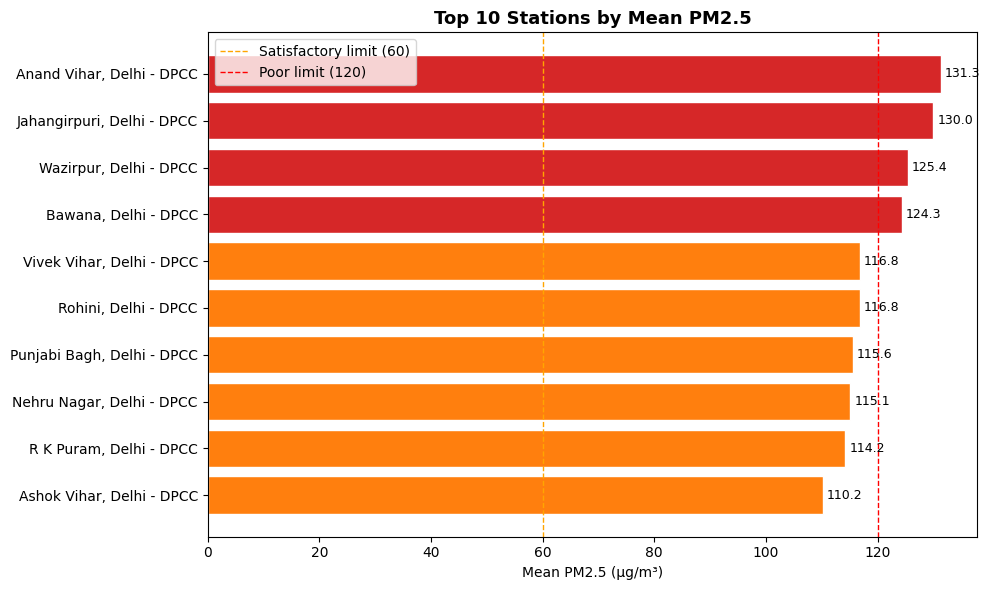

In [172]:
# ── 7b. Top 10 Stations by Mean PM2.5 ──────────────────────────────────
station_avg = pd.read_sql("""
    SELECT s.station_name, ROUND(AVG(m.avg_value), 1) AS mean_pm25
    FROM measurements m
    JOIN stations   s ON m.station_id   = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY s.station_name
    ORDER BY mean_pm25 DESC
    LIMIT 10
""", conn)

print(f"Rows fetched: {len(station_avg)}")  # confirm data is coming through

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if v > 120 else "#ff7f0e" if v > 60 else "#2ca02c"
          for v in station_avg["mean_pm25"]]
bars = ax.barh(station_avg["station_name"][::-1], station_avg["mean_pm25"][::-1],
               color=colors[::-1], edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.axvline(60, color="orange", linestyle="--", linewidth=1, label="Satisfactory limit (60)")
ax.axvline(120, color="red",    linestyle="--", linewidth=1, label="Poor limit (120)")
ax.set_xlabel("Mean PM2.5 (µg/m³)")
ax.set_title("Top 10 Stations by Mean PM2.5", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/viz_top_stations_pm25.png", dpi=120)
plt.show()

Rows fetched: 24


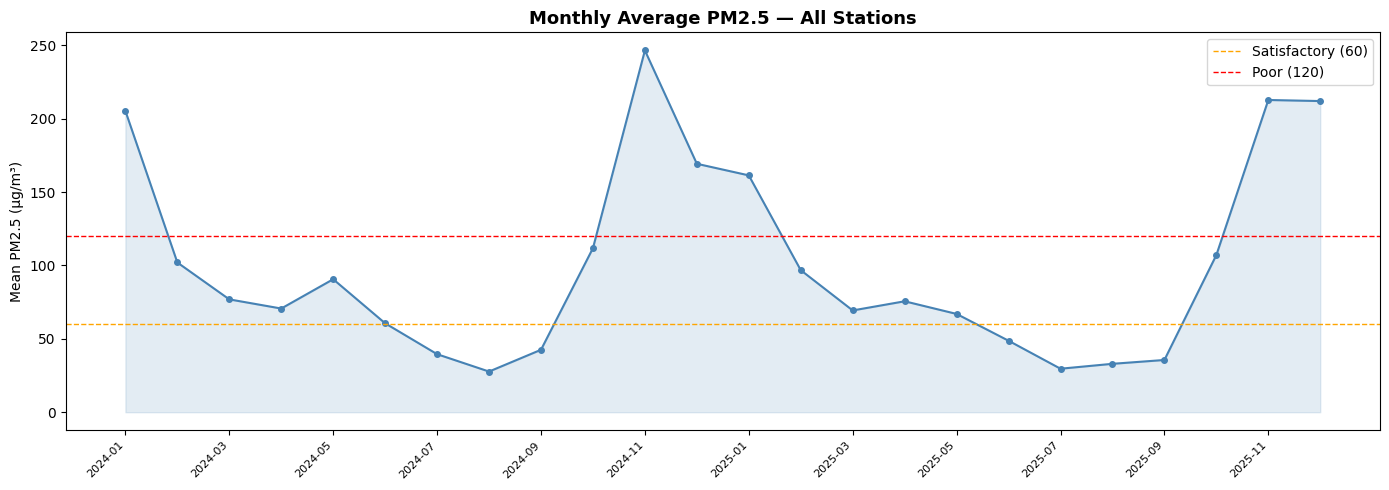

In [173]:
# ── 7c. Monthly Average PM2.5 Trend ─────────────────────────────────────
monthly = pd.read_sql("""
    SELECT m.year, m.month, ROUND(AVG(m.avg_value), 2) AS monthly_avg
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY m.year, m.month
    ORDER BY m.year, m.month
""", conn)

print(f"Rows fetched: {len(monthly)}")

if monthly.empty:
    print(" No data returned — check pollutant name in the DB")
else:
    monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
    x = list(range(len(monthly)))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x, monthly["monthly_avg"], marker="o", linewidth=1.5,
            markersize=4, color="steelblue")
    ax.fill_between(x, monthly["monthly_avg"], alpha=0.15, color="steelblue")
    ax.axhline(60,  color="orange", linestyle="--", linewidth=1, label="Satisfactory (60)")
    ax.axhline(120, color="red",    linestyle="--", linewidth=1, label="Poor (120)")

    tick_step = max(1, len(monthly) // 12)
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(monthly["period"].iloc[::tick_step], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean PM2.5 (µg/m³)")
    ax.set_title("Monthly Average PM2.5 — All Stations", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/viz_monthly_pm25_trend.png", dpi=120)
    plt.show()

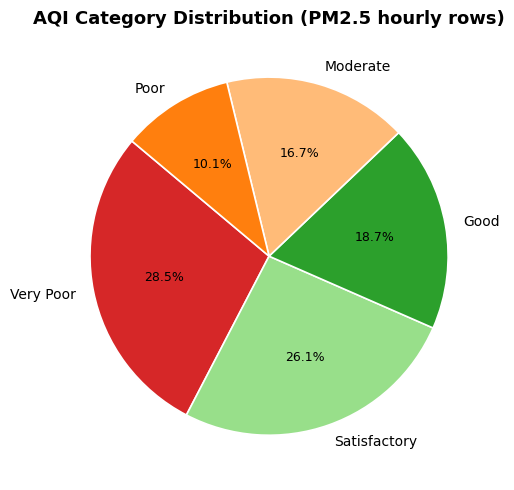

aqi_category      n
   Very Poor 172953
Satisfactory 158337
        Good 113466
    Moderate 101299
        Poor  61324


In [174]:
# ── 7d. AQI Category Breakdown ──────────────────────────────────────────
aqi_counts = pd.read_sql("""
    SELECT aqi_category, COUNT(*) AS n
    FROM measurements
    WHERE aqi_category IS NOT NULL
    GROUP BY aqi_category
    ORDER BY n DESC
""", conn)

color_map = {"Good": "#2ca02c", "Satisfactory": "#98df8a",
             "Moderate": "#ffbb78", "Poor": "#ff7f0e", "Very Poor": "#d62728"}
colors = [color_map.get(c, "grey") for c in aqi_counts["aqi_category"]]

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    aqi_counts["n"], labels=aqi_counts["aqi_category"],
    autopct="%1.1f%%", colors=colors, startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("AQI Category Distribution (PM2.5 hourly rows)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/viz_aqi_category_pie.png", dpi=120)
plt.show()

print(aqi_counts.to_string(index=False))

## Step 8 · Close Connection & Export

In [175]:
conn.close()
print(" SQLite connection closed")

 SQLite connection closed


In [176]:
import shutil, os

src  = "delhi_air_quality.db"
dest = "/kaggle/working/delhi_air_quality.db"

if os.path.exists(src):
    shutil.move(src, dest)
    size_mb = os.path.getsize(dest) / 1e6
    print(f"Database moved to {dest}  ({size_mb:.1f} MB)")
else:
    print(f" {src} not found — it may already be in /kaggle/working/")
    if os.path.exists(dest):
        size_mb = os.path.getsize(dest) / 1e6
        print(f"   Found at destination: {dest}  ({size_mb:.1f} MB)")

Database moved to /kaggle/working/delhi_air_quality.db  (881.5 MB)


## Summary

### What this notebook produced
| Artefact | Location |
|---|---|
| `delhi_air_quality.db` | `/kaggle/working/delhi_air_quality.db` |
| `viz_pm25_distribution.png` | `/kaggle/working/` |
| `viz_top_stations_pm25.png` | `/kaggle/working/` |
| `viz_monthly_pm25_trend.png` | `/kaggle/working/` |
| `viz_aqi_category_pie.png` | `/kaggle/working/` |

### Key improvements over the original notebook
| # | Improvement | Why it matters |
|---|---|---|
| 1 | **Data-quality report** (null counts) | Surfaces missing data before aggregation |
| 2 | **Outlier flagging** (3σ per station+pollutant) | Preserves data but marks suspicious readings |
| 3 | **`avg_outlier_rate` column** in measurements | Lets Member 3 filter/weight noisy hours |
| 4 | **`aqi_category` column** (CPCB PM2.5 bands) | Enables categorical analysis without extra joins |
| 5 | **Composite index** on (station_id, pollutant_id, year, month) | Speeds up Member 3's typical GROUP BY queries |
| 6 | **FK integrity assertion** | Catches insert bugs immediately |
| 7 | **Chunked insert with progress counter** | Visible feedback on long inserts |
| 8 | **4 in-notebook visualisations** | Results visible without external tools |
| 9 | **WAL mode** on SQLite | Faster writes, safer for concurrent access |

### ETL concepts used
- **Aggregation** — GROUP BY (station, pollutant, hour) → avg/min/max/count
- **3NF** — no non-key dependencies; repeated strings replaced with FKs
- **Indexes** — single-column + composite → faster WHERE / JOIN
- **ETL pattern** — raw 22M rows → 250K hourly rows before loading
- **Outlier detection** — 3σ z-score per group
- **AQI categorisation** — CPCB India PM2.5 breakpoints

### Hand-off to Member 3
`/kaggle/working/delhi_air_quality.db` is ready for SQL analytics queries.
